In [1]:
import dalmatian
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


In [13]:
# this cell may need to be run twice (google bucket connection errors)
wm = dalmatian.WorkspaceManager('rjendometrial/CDK46')
samples = wm.get_samples()
sample_sets = wm.get_sample_sets()
participants = wm.get_participants()
samples

,DMSO_indicator,Dox_indicator,MUTECT1_CS_SNV,MUTECT1_VEP_annotated_vcf,MUTECT2_VCF_ALL,MUTECT2_VCF_INDELS,MUTECT2_VEP_annotated_vcf,MuTect1_merged_coverage_wig,MuTect1_merged_power_wig,STRELKA_VEP_annotated_vcf,...,tumor_bam_insert_size_metrics,tumor_bam_lane_list,tumor_bam_pre_adapter_detail_metrics,tumor_bam_quality_by_cycle,tumor_bam_quality_by_cycle_metrics,tumor_bam_quality_distribution,tumor_bam_quality_distribution_metrics,tumor_bam_quality_yield_metrics,tumor_bam_read_coverage_lane,unmapped_unaligned_bam
sample_id,,,,,,,,,,,,,,,,,,,,,
CKDN190050174-1A,,ND,gs://fc-ecacb4b2-f185-4e48-a03a-dae1abd81260/s...,gs://fc-ecacb4b2-f185-4e48-a03a-dae1abd81260/s...,gs://fc-ecacb4b2-f185-4e48-a03a-dae1abd81260/s...,gs://fc-ecacb4b2-f185-4e48-a03a-dae1abd81260/s...,gs://fc-ecacb4b2-f185-4e48-a03a-dae1abd81260/s...,gs://fc-ecacb4b2-f185-4e48-a03a-dae1abd81260/s...,gs://fc-ecacb4b2-f185-4e48-a03a-dae1abd81260/s...,gs://fc-ecacb4b2-f185-4e48-a03a-dae1abd81260/s...,...,gs://fc-ecacb4b2-f185-4e48-a03a-dae1abd81260/s...,gs://fc-ecacb4b2-f185-4e48-a03a-dae1abd81260/s...,gs://fc-ecacb4b2-f185-4e48-a03a-dae1abd81260/s...,gs://fc-ecacb4b2-f185-4e48-a03a-dae1abd81260/s...,gs://fc-ecacb4b2-f185-4e48-a03a-dae1abd81260/s...,gs://fc-ecacb4b2-f185-4e48-a03a-dae1abd81260/s...,gs://fc-ecacb4b2-f185-4e48-a03a-dae1abd81260/s...,gs://fc-ecacb4b2-f185-4e48-a03a-dae1abd81260/s...,gs://fc-ecacb4b2-f185-4e48-a03a-dae1abd81260/s...,gs://fc-ecacb4b2-f185-4e48-a03a-dae1abd81260/f...
CKDN200001812-1A,DMSO,Dox,gs://fc-ecacb4b2-f185-4e48-a03a-dae1abd81260/s...,gs://fc-ecacb4b2-f185-4e48-a03a-dae1abd81260/s...,gs://fc-ecacb4b2-f185-4e48-a03a-dae1abd81260/s...,gs://fc-ecacb4b2-f185-4e48-a03a-dae1abd81260/s...,gs://fc-ecacb4b2-f185-4e48-a03a-dae1abd81260/s...,gs://fc-ecacb4b2-f185-4e48-a03a-dae1abd81260/s...,gs://fc-ecacb4b2-f185-4e48-a03a-dae1abd81260/s...,gs://fc-ecacb4b2-f185-4e48-a03a-dae1abd81260/s...,...,gs://fc-ecacb4b2-f185-4e48-a03a-dae1abd81260/s...,gs://fc-ecacb4b2-f185-4e48-a03a-dae1abd81260/s...,gs://fc-ecacb4b2-f185-4e48-a03a-dae1abd81260/s...,gs://fc-ecacb4b2-f185-4e48-a03a-dae1abd81260/s...,gs://fc-ecacb4b2-f185-4e48-a03a-dae1abd81260/s...,gs://fc-ecacb4b2-f185-4e48-a03a-dae1abd81260/s...,gs://fc-ecacb4b2-f185-4e48-a03a-dae1abd81260/s...,gs://fc-ecacb4b2-f185-4e48-a03a-dae1abd81260/s...,gs://fc-ecacb4b2-f185-4e48-a03a-dae1abd81260/s...,gs://fc-ecacb4b2-f185-4e48-a03a-dae1abd81260/s...
CKDN200001814-1A,DMSO,Dox,gs://fc-ecacb4b2-f185-4e48-a03a-dae1abd81260/s...,gs://fc-ecacb4b2-f185-4e48-a03a-dae1abd81260/s...,gs://fc-ecacb4b2-f185-4e48-a03a-dae1abd81260/s...,gs://fc-ecacb4b2-f185-4e48-a03a-dae1abd81260/s...,gs://fc-ecacb4b2-f185-4e48-a03a-dae1abd81260/s...,gs://fc-ecacb4b2-f185-4e48-a03a-dae1abd81260/s...,gs://fc-ecacb4b2-f185-4e48-a03a-dae1abd81260/s...,gs://fc-ecacb4b2-f185-4e48-a03a-dae1abd81260/s...,...,gs://fc-ecacb4b2-f185-4e48-a03a-dae1abd81260/s...,gs://fc-ecacb4b2-f185-4e48-a03a-dae1abd81260/s...,gs://fc-ecacb4b2-f185-4e48-a03a-dae1abd81260/s...,gs://fc-ecacb4b2-f185-4e48-a03a-dae1abd81260/s...,gs://fc-ecacb4b2-f185-4e48-a03a-dae1abd81260/s...,gs://fc-ecacb4b2-f185-4e48-a03a-dae1abd81260/s...,gs://fc-ecacb4b2-f185-4e48-a03a-dae1abd81260/s...,gs://fc-ecacb4b2-f185-4e48-a03a-dae1abd81260/s...,gs://fc-ecacb4b2-f185-4e48-a03a-dae1abd81260/s...,gs://fc-ecacb4b2-f185-4e48-a03a-dae1abd81260/s...
CKDN200001815-1A,DMSO,Dox,gs://fc-ecacb4b2-f185-4e48-a03a-dae1abd81260/s...,gs://fc-ecacb4b2-f185-4e48-a03a-dae1abd81260/s...,gs://fc-ecacb4b2-f185-4e48-a03a-dae1abd81260/s...,gs://fc-ecacb4b2-f185-4e48-a03a-dae1abd81260/s...,gs://fc-ecacb4b2-f185-4e48-a03a-dae1abd81260/s...,gs://fc-ecacb4b2-f185-4e48-a03a-dae1abd81260/s...,gs://fc-ecacb4b2-f185-4e48-a03a-dae1abd81260/s...,gs://fc-ecacb4b2-f185-4e48-a03a-dae1abd81260/s...,...,gs://fc-ecacb4b2-f185-4e48-a03a-dae1abd81260/s...,gs://fc-ecacb4b2-f185-4e48-a03a-dae1abd81260/s...,gs://fc-ecacb4b2-f185-4e48-a03a-dae1abd81260/s...,gs://fc-ecacb4b2-f185-4e48-a03a-dae1abd81260/s...,gs://fc-ecacb4b2-f185-4e48-a03a-dae1

In [14]:
covs_unfiltered = samples.loc[:, 'cov']
cov_paths = covs_unfiltered.dropna()
cov_paths = cov_paths.loc[~cov_paths.index.str.startswith("CKDN200005")]
print(cov_paths)
print(len(cov_paths.index))

sample_id
CKDN190050174-1A    gs://fc-ecacb4b2-f185-4e48-a03a-dae1abd81260/s...
CKDN200001814-1A    gs://fc-ecacb4b2-f185-4e48-a03a-dae1abd81260/s...
CKDN200001816-1A    gs://fc-ecacb4b2-f185-4e48-a03a-dae1abd81260/s...
CKDN200001817-1A    gs://fc-ecacb4b2-f185-4e48-a03a-dae1abd81260/s...
CKDN200001819-1A    gs://fc-ecacb4b2-f185-4e48-a03a-dae1abd81260/s...
CKDN200001820-1A    gs://fc-ecacb4b2-f185-4e48-a03a-dae1abd81260/s...
CKDN200001821-1A    gs://fc-ecacb4b2-f185-4e48-a03a-dae1abd81260/s...
CKDN200002461-1A    gs://fc-ecacb4b2-f185-4e48-a03a-dae1abd81260/s...
CKDN200002463-1A    gs://fc-ecacb4b2-f185-4e48-a03a-dae1abd81260/s...
CKDN200004562-1A    gs://fc-ecacb4b2-f185-4e48-a03a-dae1abd81260/s...
CKDN200004563-1A    gs://fc-ecacb4b2-f185-4e48-a03a-dae1abd81260/s...
CKDN200004564-1A    gs://fc-ecacb4b2-f185-4e48-a03a-dae1abd81260/s...
CKDN200004818-1A    gs://fc-ecacb4b2-f185-4e48-a03a-dae1abd81260/s...
CKDN200004819-1A    gs://fc-ecacb4b2-f185-4e48-a03a-dae1abd81260/s...
CKDN200004

## Getting coordinates of interesting genes

In [4]:
fn_gene_order_df = pd.read_csv("CNV_ordered_gene_list_19-11-24.txt", sep = "\t", header = None)
gene_interest = list(fn_gene_order_df[1])
gene_interest

['MCL1',
 'MDM2',
 'MDM4',
 'PPM1D',
 'AURKA',
 'CCND1',
 'CCNE1',
 'CCNE2',
 'CDK2',
 'CDK4',
 'CDK6',
 'CDKN1A',
 'CDKN1B',
 'CDKN2A',
 'CDKN2B',
 'MSI2',
 'MYC',
 'PPP2R1A',
 'RB1',
 'TOP1',
 'BRIP1',
 'NBN',
 'PARP1',
 'RAD21',
 'RAD51C',
 'RAD51D',
 'RAD52',
 'RECQL4',
 'RTEL1',
 'TERT',
 'AXIN1',
 'AXIN2',
 'NOTCH2',
 'RNF43',
 'SOX2',
 'SOX9',
 'SOX19',
 'BRD4',
 'EED',
 'ELF3',
 'ETV6',
 'HOXB13',
 'KDM5A',
 'MEF2B',
 'NCOA3',
 'NCOR1',
 'PRDM14',
 'RARA',
 'TBX3',
 'WT1',
 'ESR1',
 'FOXA1',
 'GATA3',
 'CD79B',
 'GNAS',
 'ICOSLG',
 'IKBKE',
 'IL10',
 'JAK3',
 'MPL',
 'NFKBIA',
 'PRDM1',
 'PTPRT',
 'SPOP',
 'VTCN1',
 'FH',
 'IDH2',
 'PRKAR1A',
 'SDHA',
 'SDHAF2',
 'SDHC',
 'AGO2',
 'CDC73',
 'CDK12',
 'RPS6KB2',
 'AKT2',
 'AKT3',
 'DDR2',
 'EGFR',
 'ERBB2',
 'FGF19',
 'FGF3',
 'FGF4',
 'FGFR1',
 'FGFR2',
 'IGF1R',
 'INPPL1',
 'KRAS',
 'MAP2K4',
 'NTRK1',
 'PAK1',
 'PIK3CA',
 'PIK3R2',
 'PREX2',
 'PTEN',
 'RIT1',
 'SRC',
 'YES1']

In [5]:
# SOX19 is absent in the gencode file (below), hence omitting from analysis
gene_interest.remove("SOX19")
len(gene_interest)

97

In [6]:
gencode_df = pd.read_csv("gencode.v43lift37.basic.annotation.gtf", sep = "\t", skiprows = range(0,5), header = None)

display(gencode_df)

,0,1,2,3,4,5,6,7,8
0,chr1,HAVANA,gene,12010,13670,.,+,.,"gene_id ""ENSG00000223972.6_6""; gene_type ""tran..."
1,chr1,HAVANA,transcript,12010,13670,.,+,.,"gene_id ""ENSG00000223972.6_6""; transcript_id ""..."
2,chr1,HAVANA,exon,12010,12057,.,+,.,"gene_id ""ENSG00000223972.6_6""; transcript_id ""..."
3,chr1,HAVANA,exon,12179,12227,.,+,.,"gene_id ""ENSG00000223972.6_6""; transcript_id ""..."
4,chr1,HAVANA,exon,12613,12697,.,+,.,"gene_id ""ENSG00000223972.6_6""; transcript_id ""..."
...,...,...,...,...,...,...,...,...,...
2001895,chrM,ENSEMBL,transcript,15888,15953,.,+,.,"gene_id ""ENSG00000210195.2""; transcript_id ""EN..."
2001896,chrM,ENSEMBL,exon,15888,15953,.,+,.,"gene_id ""ENSG00000210195.2""; transcript_id ""EN..."
2001897,chrM,ENSEMBL,gene,15956,16023,.,-,.,"gene_id ""ENSG00000210196.2""; gene_type ""Mt_tRN..."
2001898,chrM,ENSEMBL,transcript,15956,16023,.,-,.,"gene_id ""ENSG00000210196.2""; transcript_id ""EN..."


In [7]:
gencode_df.columns = ["chr", "convention", "type", "start", "stop", "dot1", "strand", "dot2", "gene_name"]

In [8]:
class GeneNotFoundError(Exception):
    """Raised when a gene is not found in the gencode_df."""
    pass

class GeneMappingError(Exception):
    """Raised when a gene matches multiple rows in the gencode_df."""
    pass

def process_gene(gencode_df, gene):
    """
    Process a single gene to find its coordinates in the gencode_df.

    Parameters:
        gencode_df (pd.DataFrame): DataFrame containing gene information.
        gene (str): The gene to process.

    Returns:
        dict: A dictionary with 'gene', 'start', 'stop', and 'chr'.

    Raises:
        GeneNotFoundError: If the gene is not found in the gencode_df.
        GeneMappingError: If the gene matches multiple rows in the gencode_df.
    """
    gencode_df_gene = gencode_df.loc[gencode_df["type"] == "gene"]
    row_gene = gencode_df_gene.loc[gencode_df_gene["gene_name"].str.contains(f'gene_name "{gene}"')]

    if len(row_gene.index) == 0:
        raise GeneNotFoundError(f"Gene '{gene}' is not found in the gencode_df.")
    elif len(row_gene.index) > 1:
        raise GeneMappingError(f"Gene '{gene}' matches multiple rows in the gencode_df.")

    gene_start = row_gene.iloc[0]["start"]
    gene_stop = row_gene.iloc[0]["stop"]

    if row_gene.iloc[0]["chr"] != "chrX":
        gene_chr = int(row_gene.iloc[0]["chr"].replace("chr", ""))
    else:
        return None  # Exclude genes on chromosome X

    return {"gene": gene, "start": gene_start, "stop": gene_stop, "chr": gene_chr}





In [9]:
# Wrapper to process all genes
def process_all_genes(gencode_df, gene_interest):
    """
    Process all genes and build a DataFrame with their coordinates.

    Parameters:
        gencode_df (pd.DataFrame): DataFrame containing gene information.
        gene_interest (list): List of genes to process.

    Returns:
        pd.DataFrame: DataFrame with gene coordinates.
    """
    results = []

    for gene in gene_interest:
        print(f"Processing gene: {gene}")
        try:
            gene_data = process_gene(gencode_df, gene)
            if gene_data:
                results.append(gene_data)
        except (GeneNotFoundError, GeneMappingError) as e:
            print(f"Error processing gene '{gene}': {e}")

    return pd.DataFrame(results, columns=["gene", "chr", "start", "stop"])

In [10]:
# Unit test cases
def test_process_gene():
    test_df = pd.DataFrame({
        "type": ["gene", "gene", "gene"],
        "gene_name": ['gene_name "A"', 'gene_name "B"', 'gene_name "A"'],
        "chr": ["chr1", "chr2", "chr1"],
        "start": [100, 200, 300],
        "stop": [150, 250, 350]
    })

    # Test for a valid single match
    assert process_gene(test_df, "B") == {"gene": "B", "chr": 2, "start": 200, "stop": 250}

    # Test for no matches
    try:
        process_gene(test_df, "C")
    except GeneNotFoundError as e:
        assert str(e) == "Gene 'C' is not found in the gencode_df."

    # Test for multiple matches
    try:
        process_gene(test_df, "A")
    except GeneMappingError as e:
        assert str(e) == "Gene 'A' matches multiple rows in the gencode_df."

# Run unit tests
test_process_gene()
print("All tests passed!")

All tests passed!


In [11]:
gene_coords_df = process_all_genes(gencode_df, gene_interest)

Processing gene: MCL1
Processing gene: MDM2
Processing gene: MDM4
Processing gene: PPM1D
Processing gene: AURKA
Processing gene: CCND1
Processing gene: CCNE1
Processing gene: CCNE2
Processing gene: CDK2
Processing gene: CDK4
Processing gene: CDK6
Processing gene: CDKN1A
Processing gene: CDKN1B
Processing gene: CDKN2A
Processing gene: CDKN2B
Processing gene: MSI2
Processing gene: MYC
Processing gene: PPP2R1A
Processing gene: RB1
Processing gene: TOP1
Processing gene: BRIP1
Processing gene: NBN
Processing gene: PARP1
Processing gene: RAD21
Processing gene: RAD51C
Processing gene: RAD51D
Processing gene: RAD52
Processing gene: RECQL4
Processing gene: RTEL1
Processing gene: TERT
Processing gene: AXIN1
Processing gene: AXIN2
Processing gene: NOTCH2
Processing gene: RNF43
Processing gene: SOX2
Processing gene: SOX9
Processing gene: BRD4
Processing gene: EED
Processing gene: ELF3
Processing gene: ETV6
Processing gene: HOXB13
Processing gene: KDM5A
Processing gene: MEF2B
Processing gene: NCOA3

In [18]:
gene_coords_df.loc[gene_coords_df["gene"] == "CDKN1A"]

,gene,chr,start,stop
11,CDKN1A,6,36644237,36655114


## Normalization w.r.t Parental cell-line

The total number of reads mapping to a gene in a tumor cell-line is calculated, and the proportion of such reads is calculated relative to all the reads in that sample. The same procedure is done with the Parental cell-line, and the read fraction in the tumor cell-line is normalized by that in the Parental cell-line. This is done for each of the genes in each sample. 

So the CN for a gene A in Tumor T would be calculated as,

$
CN_{gene_A}^{T} = \frac{NumReads_{gene_A}^{T}}{NumReads_{gene_A}^{Parental}} * \frac{\sum_{i=0}^{n}NumReads_{gene_i}^{Parental}}{\sum_{i=0}^{n}NumReads_{gene_i}^{T}}
$

In [30]:
normal = "CKDN190050174-1A" #Normalized wrt Parental
normals_sum_genes_df = {x:None for x in gene_coords_df['gene'].to_list()}


cov_df = pd.read_csv(samples.loc[normal, 'cov'], sep = "\t", header = 3)
cov_df["contig"] = cov_df["contig"].astype(str)

total_reads_normal = cov_df.iloc[:, -1].sum()

for i in range(len(gene_coords_df.index)):
    gene_chr = str(gene_coords_df.iloc[i, 1])
    gene_start = gene_coords_df.iloc[i, 2]
    gene_stop = gene_coords_df.iloc[i, 3]
    cov_df_gene = cov_df.loc[(cov_df['contig'] == gene_chr)]

    cov_df_gene_range = cov_df.loc[(cov_df['contig'] == gene_chr) & (cov_df['start'] <= gene_stop) & 
                        (cov_df['stop'] >= gene_start)]

    normals_sum_genes_df[gene_coords_df.iloc[i, 0]] = (cov_df_gene_range.iloc[:, -1]).sum()


print(normals_sum_genes_df)
print(total_reads_normal)

/var/folders/q_/j_57k8z50v17pvnyw6788yc00000gq/T/ipykernel_95358/14885017.py:5: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  cov_df = pd.read_csv(samples.loc[normal, 'cov'], sep = "\t", header = 3)


{'MCL1': 1748, 'MDM2': 1340, 'MDM4': 2838, 'PPM1D': 13902, 'AURKA': 1828, 'CCND1': 1606, 'CCNE1': 1256, 'CCNE2': 1541, 'CDK2': 1717, 'CDK4': 1715, 'CDK6': 1004, 'CDKN1A': 614, 'CDKN1B': 567, 'CDKN2A': 51, 'CDKN2B': 93, 'MSI2': 2878, 'MYC': 3893, 'PPP2R1A': 1985, 'RB1': 1685, 'TOP1': 4469, 'BRIP1': 35479, 'NBN': 4372, 'PARP1': 2977, 'RAD21': 1758, 'RAD51C': 9694, 'RAD51D': 736, 'RAD52': 1289, 'RECQL4': 8126, 'RTEL1': 8540, 'TERT': 3383, 'AXIN1': 3960, 'AXIN2': 3854, 'NOTCH2': 14295, 'RNF43': 5390, 'SOX2': 749, 'SOX9': 2382, 'BRD4': 2578, 'EED': 1074, 'ELF3': 876, 'ETV6': 970, 'HOXB13': 842, 'KDM5A': 3089, 'MEF2B': 1473, 'NCOA3': 38044, 'NCOR1': 4609, 'PRDM14': 1292, 'RARA': 1159, 'TBX3': 1481, 'WT1': 865, 'ESR1': 2213, 'FOXA1': 1838, 'GATA3': 1709, 'CD79B': 3385, 'GNAS': 12879, 'ICOSLG': 2075, 'IKBKE': 7941, 'IL10': 1445, 'JAK3': 3527, 'MPL': 1863, 'NFKBIA': 1274, 'PRDM1': 2191, 'PTPRT': 9046, 'SPOP': 1871, 'VTCN1': 1010, 'FH': 805, 'IDH2': 2107, 'PRKAR1A': 5334, 'SDHA': 2341, 'SDHAF2':

In [45]:
cell_lines = cov_paths.index.to_list()
cell_lines = [x.split("_")[0] for x in cell_lines]
print(cell_lines)

cell_line_genes_df = {x:[] for x in gene_coords_df['gene'].to_list()}
cell_line_genes_cnv_df = {x:0 for x in gene_coords_df['gene'].to_list()}
cell_lines_hmap = pd.DataFrame(index = cell_lines, columns = gene_coords_df['gene'])


for sample in cell_lines:
    cov_df = pd.read_csv(samples.loc[sample, 'cov'], sep = "\t", header = 3)
    cov_df["contig"] = cov_df["contig"].astype(str)
    total_reads_cell_line = cov_df.iloc[:, -1].sum()
    for i in range(len(gene_coords_df.index)):
        gene_chr = str(gene_coords_df.iloc[i, 1])
        gene_start = gene_coords_df.iloc[i, 2]
        gene_stop = gene_coords_df.iloc[i, 3]
        cov_df_gene_range = cov_df.loc[(cov_df['contig'] == gene_chr) & (cov_df['start'] <= gene_stop) & 
                            (cov_df['stop'] >= gene_start)]

        gene = gene_coords_df.iloc[i, 0]
        cell_line_genes_df[gene] = (cov_df_gene_range.iloc[:, -1]).sum()
        if (cell_line_genes_df[gene]) == 0 and (normals_sum_genes_df[gene] == 0): 
            cell_line_genes_cnv_df[gene] = 1 #No CN change if neither Tumor nor Normal has any reads supporting CN change
        else:
            cell_line_genes_cnv_df[gene] = (cell_line_genes_df[gene] * total_reads_normal)/(normals_sum_genes_df[gene] * total_reads_cell_line)

    cell_lines_hmap.loc[sample, :] = pd.Series(cell_line_genes_cnv_df)


['CKDN190050174-1A', 'CKDN200001814-1A', 'CKDN200001816-1A', 'CKDN200001817-1A', 'CKDN200001819-1A', 'CKDN200001820-1A', 'CKDN200001821-1A', 'CKDN200002461-1A', 'CKDN200002463-1A', 'CKDN200004562-1A', 'CKDN200004563-1A', 'CKDN200004564-1A', 'CKDN200004818-1A', 'CKDN200004819-1A', 'CKDN200004820-1A', 'USD16091271', 'USD16091272', 'USD16091274', 'USD16091277', 'USD16091279', 'USD16091280', 'USD16091282', 'USD16091450', 'USD16091451', 'USD16091453', 'USD16091454', 'USD16091488']


/var/folders/q_/j_57k8z50v17pvnyw6788yc00000gq/T/ipykernel_95358/855029471.py:11: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  cov_df = pd.read_csv(samples.loc[sample, 'cov'], sep = "\t", header = 3)
/var/folders/q_/j_57k8z50v17pvnyw6788yc00000gq/T/ipykernel_95358/855029471.py:11: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  cov_df = pd.read_csv(samples.loc[sample, 'cov'], sep = "\t", header = 3)
/var/folders/q_/j_57k8z50v17pvnyw6788yc00000gq/T/ipykernel_95358/855029471.py:11: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  cov_df = pd.read_csv(samples.loc[sample, 'cov'], sep = "\t", header = 3)
/var/folders/q_/j_57k8z50v17pvnyw6788yc00000gq/T/ipykernel_95358/855029471.py:11: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  cov_df = pd.read_csv(samples.loc[sample, 'cov

In [46]:
samples_to_annotations = {'CKDN200002460-1A': 'NDDMSO3_2_CKDN200002460',
 'CKDN200001812-1A': 'DOXDMSO3_2_CKDN200001812',
 'CKDN200004820-1A': 'DXABR_3_CKDN200004820',
 'USD16091279': 'DOXDMSO3_USD16091279',
 'CKDN200001814-1A': 'DOXDMSO3_6_CKDN200001814',
 'CKDN200004818-1A': 'DXABR_1_CKDN200004818',
 'USD16091450': 'NDDMSO3_USD16091450',
 'CKDN200001816-1A': 'DOXDMSO3_9_CKDN200001816',
 'CKDN200004562-1A': 'NDABR_1_CKDN200004562',
 'USD16091453': 'DOXDMSO2_USD16091453',
 'USD16091280': 'DOXPDR1_USD16091280',
 'USD16091272': 'NDDMSO2_USD16091272',
 'USD16091451': 'NDPDR2_USD16091451',
 'USD16091274': 'NDPDR1_USD16091274',
 'CKDN200004563-1A': 'NDABR_2_CKDN200004563',
 'USD16091282': 'DOXPDR3_USD16091282',
 'CKDN200001820-1A': 'DOXPR3_1_CKDN200001820',
 'USD16091454': 'DOXPDR2_USD16091454',
 'CKDN200002461-1A': 'NDDMSO3_5_CKDN200002461',
 'CKDN200002462-1A': 'NDDMSO3_6_CKDN200002462',
 'CKDN200004564-1A': 'NDABR_3_CKDN200004564',
 'USD16091277': 'DOXDMSO1_USD16091277',
 'CKDN200001817-1A': 'NDPR3_1_CKDN200001817',
 'CKDN200002464-1A': 'DOXDMSO3_3_CKDN200002464',
 'CKDN200001819-1A': 'NDPR3_15_CKDN200001819',
 'CKDN200004819-1A': 'DXABR_2_CKDN200004819',
 'USD16091488': 'NDPDR3_USD16091488',
 'CKDN200001818-1A': 'NDPR3_2_CKDN200001818',
 'USD16091271': 'NDDMSO1_USD16091271',
 'CKDN200002463-1A': 'NDDMSO3_7_CKDN200002463',
 'CKDN200001821-1A': 'DOXPR3_2_CKDN200001821',
 'CKDN200001815-1A': 'DOXDMSO3_7_CKDN200001815',
 'CKDN190050174-1A': 'Basal_CKDN190050174'}

In [47]:
cell_lines_hmap.rename(index=samples_to_annotations,inplace=True)
cell_lines_hmap = cell_lines_hmap[cell_lines_hmap.columns].astype(float)
cell_lines_hmap

gene,MCL1,MDM2,MDM4,PPM1D,AURKA,CCND1,CCNE1,CCNE2,CDK2,CDK4,...,MAP2K4,NTRK1,PAK1,PIK3CA,PIK3R2,PREX2,PTEN,RIT1,SRC,YES1
Basal_CKDN190050174,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
DOXDMSO3_6_CKDN200001814,0.845916,1.183248,1.081203,0.929656,0.891734,0.873170,1.108384,1.072677,1.037330,1.196089,...,1.099820,0.976271,1.021010,1.146190,0.864664,0.817462,1.051021,1.088092,1.009771,1.063844
DOXDMSO3_9_CKDN200001816,1.048278,1.215103,1.443968,1.083473,0.893445,0.778213,1.157613,1.098617,1.145505,1.509765,...,1.183791,0.916923,1.432199,1.124655,0.651406,0.994040,0.903506,1.357464,0.692400,1.370589
NDPR3_1_CKDN200001817,0.996369,1.181720,1.010181,1.033727,0.791905,1.094037,1.201177,1.361974,1.042391,1.163887,...,0.945970,1.253715,0.743872,0.817968,1.170329,0.551889,0.720057,1.048013,1.272080,1.095567
NDPR3_15_CKDN200001819,1.101412,1.180303,0.921534,1.002994,0.782385,1.264587,1.296099,1.233459,1.059444,1.287423,...,0.711337,1.371180,0.514428,0.669627,1.270363,0.414582,0.568787,1.091180,1.397631,0.976028
DOXPR3_1_CKDN200001820,1.496346,0.840879,0.429224,0.586345,0.336891,1.841450,0.792048,1.007869,0.878939,1.106860,...,0.477642,1.783039,0.542302,0.488451,1.610315,0.415993,0.450253,1.117302,1.391309,1.020565
DOXPR3_2_CKDN200001821,1.316713,0.985101,0.593266,0.893134,0.500315,1.674190,0.966175,1.162834,0.759798,0.789402,...,0.632249,1.451007,0.676332,0.702554,1.339973,0.685568,0.630414,0.856670,1.606410,0.770565
NDDMSO3_5_CKDN200002461,1.212250,1.498952,1.904675,0.945071,1.377056,0.943226,1.338429,1.890345,1.023871,1.389661,...,1.537434,0.602196,0.800632,1.298830,0.761267,1.221041,1.315678,0.982598,0.796552,1.380507
NDDMSO3_7_CKDN200002463,1.508407,1.155770,1.384895,1.152720,1.105649,1.260748,0.878364,1.073402,1.086970,1.399707,...,1.033450,1.198300,0.485837,0.834983,0.838323,0.700641,0.764859,0.988090,1.101991,0.887438
NDABR_1_CKDN200004562,1.055714,0.715854,0.814795,1.044653,0.981318,1.480776,0.963036,0.844992,0.764502,0.914425,...,0.829877,1.087675,0.833559,0.758199,1.111870,0.891793,0.784611,0.881240,1.101839,0.809257


In [48]:
sample_vs_cluster_2 = {'NDDMSO3_7_CKDN200002463': 'g', #g #This dict has colours corresponding to the actual biol. diffs
                     'NDDMSO3_6_CKDN200002462': 'g', 
                     'DOXDMSO3_USD16091279': 'r', 
                     'NDPDR1_USD16091274': 'c', #c
                     'DOXDMSO3_9_CKDN200001816': 'r', #r
                     'DOXPDR3_USD16091282': 'm', 
                     'DXABR_1_CKDN200004818': 'y', 
                     'DOXDMSO2_USD16091453': 'r', 
                     'NDPR3_15_CKDN200001819': 'c', 
                     'DXABR_3_CKDN200004820': 'y', 
                     'NDDMSO2_USD16091272': 'g', 
                     'NDABR_2_CKDN200004563': 'y', 
                     'DOXPDR1_USD16091280': 'm', 
                     'NDPDR2_USD16091451': 'c', 
                     'DOXPDR2_USD16091454': 'm', 
                     'NDDMSO3_USD16091450': 'g', 
                     'NDABR_3_CKDN200004564': 'y', 
                     'NDABR_1_CKDN200004562': 'y', 
                     'DOXDMSO3_7_CKDN200001815': 'r', 
                     'DOXDMSO3_6_CKDN200001814': 'r', 
                     'DOXPR3_2_CKDN200001821': 'm', 
                     'NDDMSO3_2_CKDN200002460': 'g', 
                     'NDDMSO3_5_CKDN200002461': 'g', 
                     'DOXDMSO1_USD16091277': 'r', 
                     'NDDMSO1_USD16091271': 'g', 
                     'NDPR3_1_CKDN200001817': 'c', 
                     'DOXPR3_1_CKDN200001820': 'm', 
                     'DOXDMSO3_3_CKDN200002464': 'r', 
                     'DXABR_2_CKDN200004819': 'y', 
                     'DOXDMSO3_2_CKDN200001812': 'r', 
                     'NDPDR3_USD16091488': 'c'}

## Bulk + specific_clones + Abema

In [49]:
bulk_and_specific_clones_w_abema_samples = ['NDDMSO1_USD16091271', 'NDDMSO2_USD16091272', 'NDDMSO3_USD16091450',
                                            'NDDMSO3_5_CKDN200002461','NDDMSO3_7_CKDN200002463',  
                                            'DOXDMSO1_USD16091277', 'DOXDMSO2_USD16091453','DOXDMSO3_USD16091279',
                                            'DOXDMSO3_6_CKDN200001814', 'DOXDMSO3_9_CKDN200001816', 
                                            'NDPDR1_USD16091274', 'NDPDR2_USD16091451', 'NDPDR3_USD16091488',
                                            'NDPR3_1_CKDN200001817', 'NDPR3_15_CKDN200001819', 
                                              'DOXPDR1_USD16091280',
                                            'DOXPDR2_USD16091454', 'DOXPR3_2_CKDN200001821', 'DOXPDR3_USD16091282',
                                            'DOXPR3_1_CKDN200001820', 'NDABR_1_CKDN200004562','NDABR_2_CKDN200004563',
                                            'NDABR_3_CKDN200004564',
                                            'DXABR_1_CKDN200004818',  
                                            'DXABR_2_CKDN200004819', 
                                            'DXABR_3_CKDN200004820']

In [50]:
len(bulk_and_specific_clones_w_abema_samples)

26

In [51]:
cell_lines_hmap_reorder_bulk_sp_cl_abema = cell_lines_hmap.loc[bulk_and_specific_clones_w_abema_samples].reindex(bulk_and_specific_clones_w_abema_samples)


In [52]:
#Renaming the mislabelled sample by Novogene

#'DOXPR2_2_CKDN200001821'
cell_lines_hmap_reorder_bulk_sp_cl_abema.rename(index = {"DOXPR3_2_CKDN200001821" : "DOXPR2_2_CKDN200001821"}, inplace = True)

In [53]:
#Finding max value to provide to colour scale
max(np.log2(cell_lines_hmap_reorder_bulk_sp_cl_abema.max(axis=1)))

1.5082269440657914

In [54]:
#Finding min value to provide to colour scale
min(np.log2(cell_lines_hmap_reorder_bulk_sp_cl_abema.min(axis=1)))

-2.1452009023383325

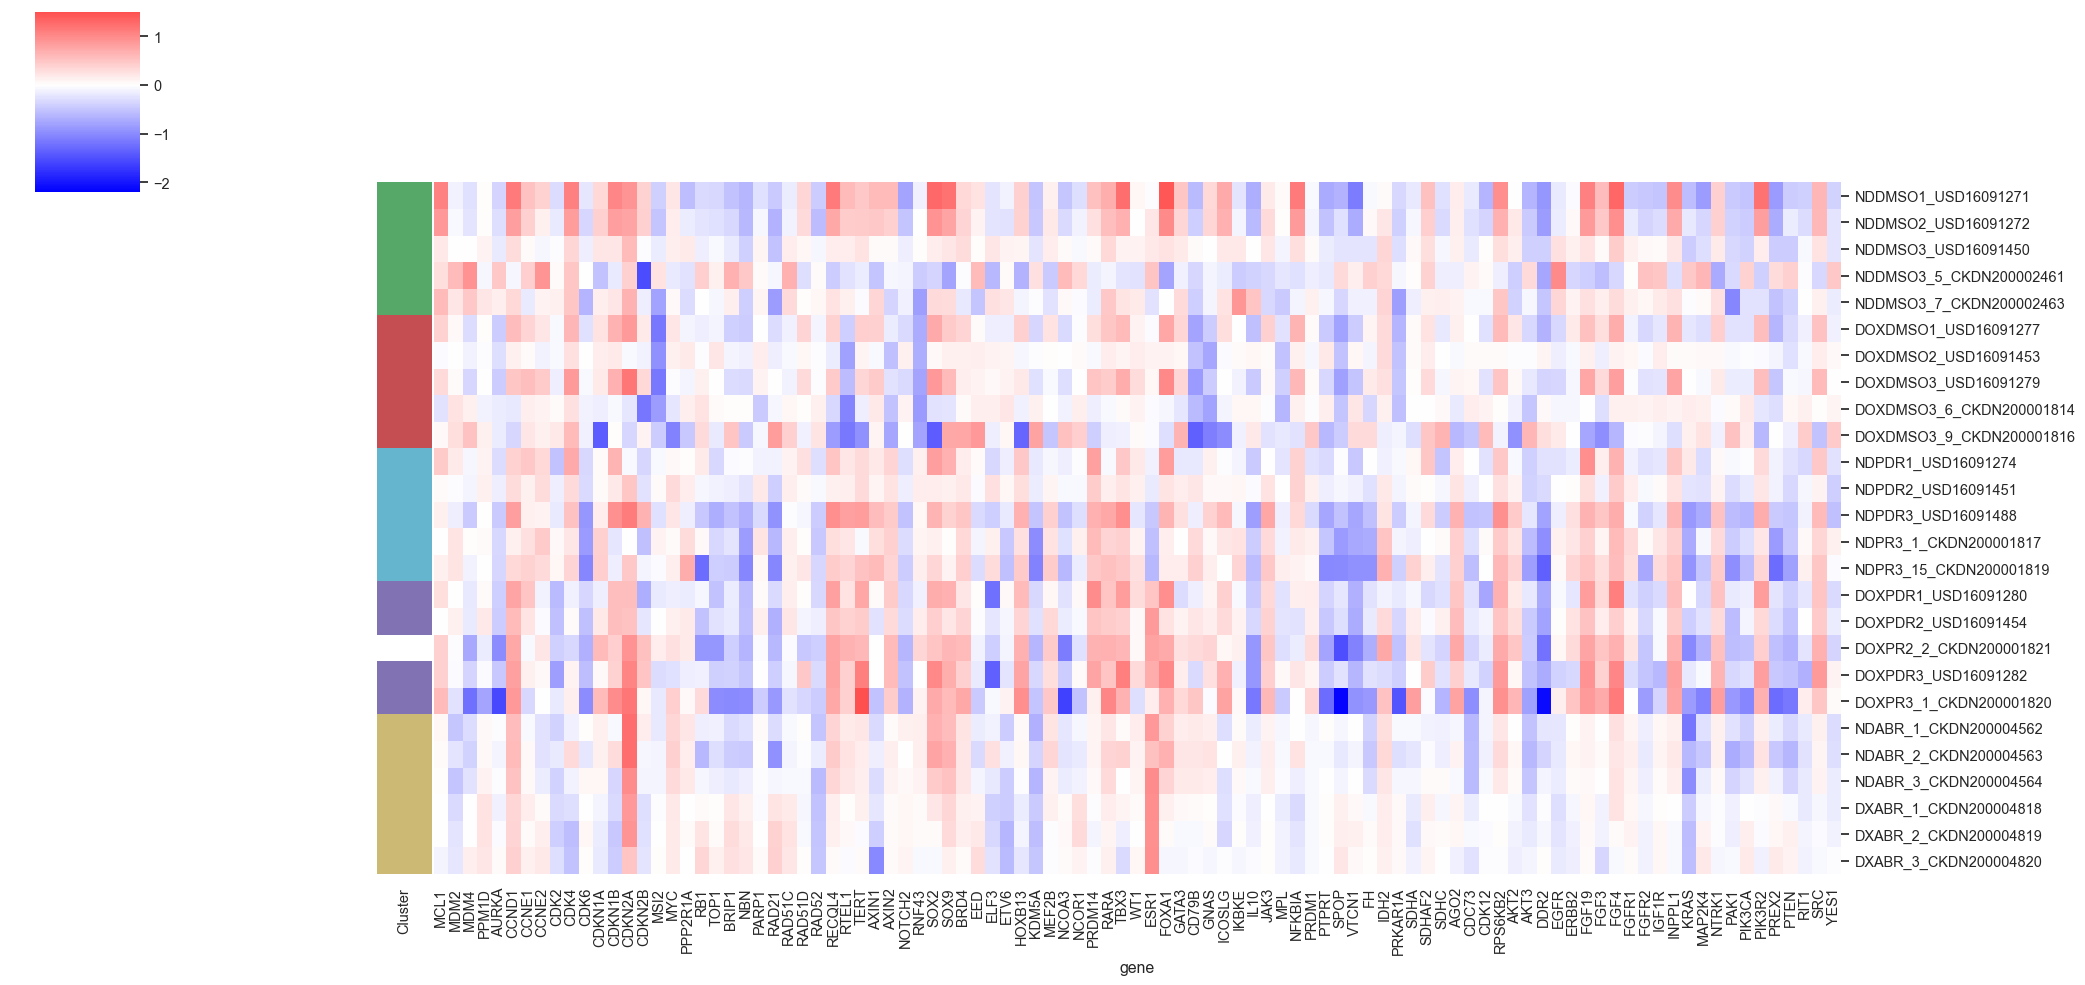

In [56]:
sns.set(rc={'figure.figsize':(35,10)})
sns.set(font_scale=0.95)
g1 = sns.clustermap(np.log2(cell_lines_hmap_reorder_bulk_sp_cl_abema[gene_interest]), vmin = -2.2, vmax = 1.5, center = 0, fmt='f', cmap = "bwr",
               col_cluster = False, row_cluster = False, tree_kws=dict(linewidths=0.8),
               metric = 'euclidean', row_colors = pd.Series(sample_vs_cluster_2, name = "Cluster"),
               figsize=(21, 10), xticklabels=True)
g1.savefig("bulk_and_specific_clones_and_Abema_log2_ordered_samples_fixed.pdf", format="pdf", bbox_inches="tight")
plt.show()

In [57]:
np.log2(cell_lines_hmap_reorder_bulk_sp_cl_abema[gene_interest]).to_csv("bulk_and_specific_clones_and_Abema_log2_ordered_samples_fixed_table.txt", sep = "\t")